In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ML
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
import shap
import optuna
import mlflow
import mlflow.xgboost
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)

NOTEBOOK_DIR = Path().resolve()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
MODELS_DIR = ROOT_DIR / "models" / "xgboost"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading train/test splits...")
X_train = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
X_test  = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["TARGET"]
y_test  = pd.read_csv(PROCESSED_DIR / "y_test.csv")["TARGET"]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape} | default rate: {y_train.mean()*100:.1f}%")
print(f"y_test:  {y_test.shape}  | default rate: {y_test.mean()*100:.1f}%")
print("\nAll data loaded!")

Loading train/test splits...
X_train: (293992, 251)
X_test:  (61503, 251)
y_train: (293992,) | default rate: 23.1%
y_test:  (61503,)  | default rate: 8.1%

All data loaded!


In [2]:
print("=" * 50)
print("BASELINE XGBOOST MODEL")
print("=" * 50)

# Set up MLflow (Windows file path must be a valid URI scheme)
mlflow_tracking_path = str(ROOT_DIR / "mlflow_runs").replace("\\", "/")
mlflow.set_tracking_uri(f"file:///{mlflow_tracking_path}")
mlflow.set_experiment("creditiq_xgboost")

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

with mlflow.start_run(run_name="baseline_xgboost"):

    # Baseline model
    baseline_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric="auc",
        early_stopping_rounds=20,
        verbosity=0
    )

    print("Training baseline model...")
    baseline_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    # Predictions
    y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    # ── Banking Metrics ───────────────────────────────────────
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # KS Statistic
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    ks_stat = max(tpr - fpr)

    # Gini Coefficient
    gini = 2 * roc_auc - 1

    print(f"\n{'='*40}")
    print(f"BASELINE MODEL RESULTS")
    print(f"{'='*40}")
    print(f"ROC-AUC:       {roc_auc:.4f}")
    print(f"KS Statistic:  {ks_stat:.4f}")
    print(f"Gini:          {gini:.4f}")
    print(f"{'='*40}")

    # Log to MLflow
    mlflow.log_metrics({
        "roc_auc":      roc_auc,
        "ks_statistic": ks_stat,
        "gini":         gini
    }) # type: ignore
    mlflow.log_params({
        "n_estimators":  300,
        "max_depth":     6,
        "learning_rate": 0.05,
        "model_type":    "baseline"
    })
    mlflow.xgboost.log_model(baseline_model, "baseline_xgboost")

print("\nBaseline model trained!")

BASELINE XGBOOST MODEL
scale_pos_weight: 3.33
Training baseline model...

BASELINE MODEL RESULTS
ROC-AUC:       0.7832
KS Statistic:  0.4271
Gini:          0.5663

Baseline model trained!


In [ ]:
print("=" * 50)
print("HYPERPARAMETER TUNING WITH OPTUNA")
print("=" * 50)
print("Running 50 trials — takes ~10-15 minutes...")

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "max_depth":         trial.suggest_int("max_depth", 3, 9),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0, 2),
        "scale_pos_weight":  scale_pos_weight,
        "random_state":      42,
        "n_jobs":            -1,
        "verbosity":         0,
        "eval_metric":       "auc",
        "early_stopping_rounds": 20,
    }

    model = XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_pred = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest ROC-AUC: {study.best_value:.4f}")
print(f"Best params:")

for k, v in study.best_params.items():
    print(f"  {k:<25} {v}")

HYPERPARAMETER TUNING WITH OPTUNA
Running 50 trials — takes ~10-15 minutes...


Best trial: 40. Best value: 0.787478: 100%|██████████| 50/50 [1:45:46<00:00, 126.93s/it]  


Best ROC-AUC: 0.7875
Best params:
  n_estimators              661
  max_depth                 5
  learning_rate             0.054934063482679936
  subsample                 0.7985660824374922
  colsample_bytree          0.835781288969878
  min_child_weight          10
  gamma                     1.2510873769091466
  reg_alpha                 1.3744358880947887
  reg_lambda                1.212414778963846


In [5]:
print("=" * 50)
print("TRAINING FINAL TUNED MODEL")
print("=" * 50)

best_params = study.best_params
best_params.update({
    "scale_pos_weight":      scale_pos_weight,
    "random_state":          42,
    "n_jobs":                -1,
    "verbosity":             0,
    "eval_metric":           "auc",
    "early_stopping_rounds": 20,
})

with mlflow.start_run(run_name="tuned_xgboost"):

    final_model = XGBClassifier(**best_params)

    print("Training final model on full training set...")
    final_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100
    )

    # Predictions
    y_pred_proba = final_model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    # ── Banking Metrics ───────────────────────────────────────
    roc_auc  = roc_auc_score(y_test, y_pred_proba)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    ks_stat  = max(tpr - fpr)
    gini     = 2 * roc_auc - 1

    print(f"\n{'='*45}")
    print(f"FINAL TUNED MODEL RESULTS")
    print(f"{'='*45}")
    print(f"ROC-AUC:       {roc_auc:.4f}")
    print(f"KS Statistic:  {ks_stat:.4f}")
    print(f"Gini:          {gini:.4f}")
    print(f"{'='*45}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=["Repaid", "Defaulted"]))

    # Log to MLflow
    mlflow.log_metrics({
        "roc_auc":      roc_auc,
        "ks_statistic": ks_stat,
        "gini":         gini
    })
    mlflow.log_params(best_params)
    mlflow.xgboost.log_model(final_model, "tuned_xgboost")

    # Save model locally
    model_path = MODELS_DIR / "xgboost_final.pkl"
    joblib.dump(final_model, model_path)
    print(f"\nModel saved to: {model_path}")

TRAINING FINAL TUNED MODEL
Training final model on full training set...
[0]	validation_0-auc:0.68338
[100]	validation_0-auc:0.76027
[200]	validation_0-auc:0.77490
[300]	validation_0-auc:0.78130
[400]	validation_0-auc:0.78422
[500]	validation_0-auc:0.78609
[600]	validation_0-auc:0.78705
[660]	validation_0-auc:0.78746

FINAL TUNED MODEL RESULTS
ROC-AUC:       0.7875
KS Statistic:  0.4342
Gini:          0.5750

Classification Report:
              precision    recall  f1-score   support

      Repaid       0.94      0.95      0.95     56538
   Defaulted       0.34      0.28      0.31      4965

    accuracy                           0.90     61503
   macro avg       0.64      0.62      0.63     61503
weighted avg       0.89      0.90      0.89     61503


Model saved to: C:\Users\Pavan\Downloads\creditiq_sqlserver\creditiq\models\xgboost\xgboost_final.pkl


MODEL EVALUATION PLOTS


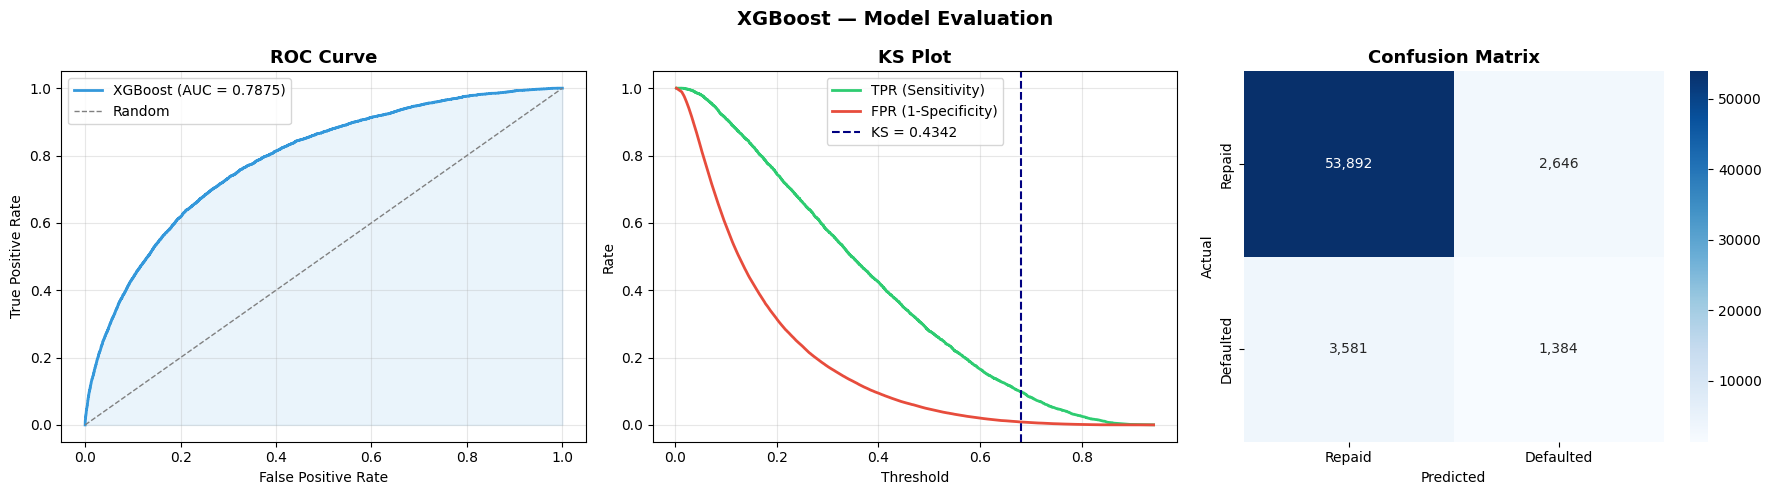

Plots saved!


In [6]:
print("=" * 50)
print("MODEL EVALUATION PLOTS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: ROC Curve ─────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color="#3498db", lw=2,
             label=f"XGBoost (AUC = {roc_auc:.4f})")
axes[0].plot([0,1], [0,1], color="gray",
             linestyle="--", lw=1, label="Random")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#3498db")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: KS Plot ───────────────────────────────────────────
axes[1].plot(thresholds if len(thresholds)==len(tpr)
             else np.linspace(0,1,len(tpr)),
             tpr, color="#2ecc71", lw=2, label="TPR (Sensitivity)")
axes[1].plot(thresholds if len(thresholds)==len(fpr)
             else np.linspace(0,1,len(fpr)),
             fpr, color="#e74c3c", lw=2, label="FPR (1-Specificity)")

thresholds_plot = np.linspace(0, 1, len(tpr))
ks_idx = np.argmax(tpr - fpr)
axes[1].axvline(x=thresholds_plot[ks_idx],
                color="navy", linestyle="--",
                label=f"KS = {ks_stat:.4f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Rate")
axes[1].set_title("KS Plot", fontsize=13, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Plot 3: Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
            xticklabels=["Repaid", "Defaulted"],
            yticklabels=["Repaid", "Defaulted"],
            ax=axes[2])
axes[2].set_title("Confusion Matrix", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Actual")
axes[2].set_xlabel("Predicted")

plt.suptitle("XGBoost — Model Evaluation",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "11_xgboost_evaluation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved!")

SHAP EXPLAINABILITY
Computing SHAP values (takes 2-3 minutes)...


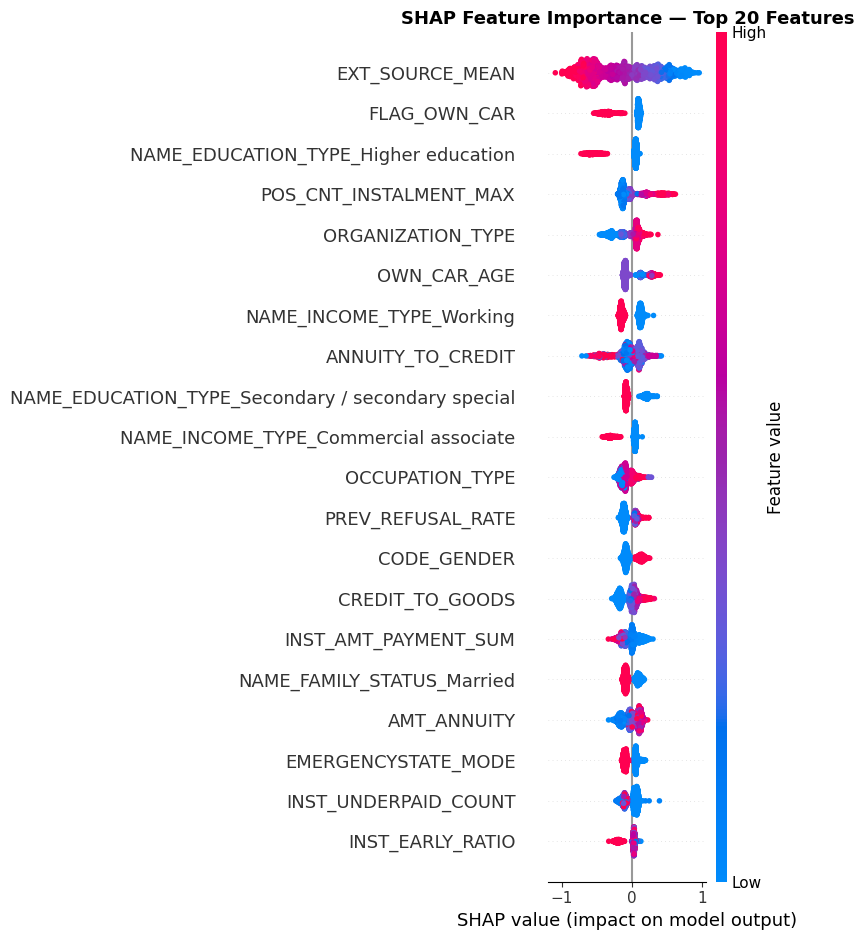

SHAP summary plot saved!


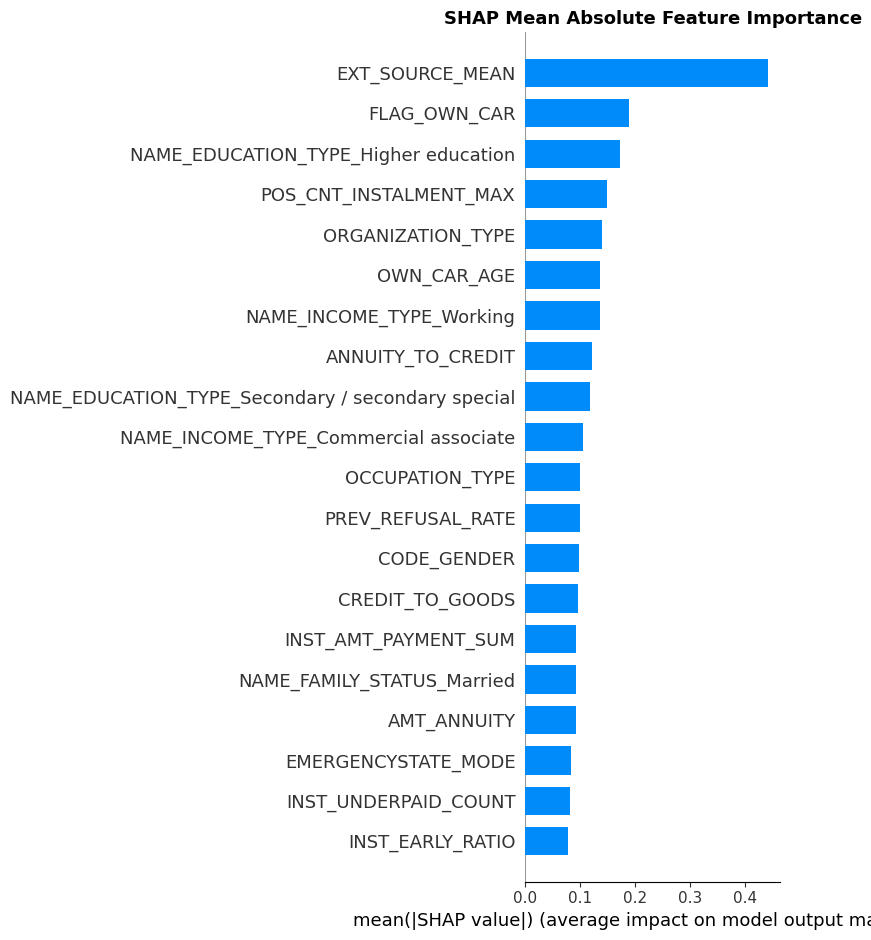


Top 15 most important features (SHAP):
                                          feature  importance
                                  EXT_SOURCE_MEAN    0.440811
                                     FLAG_OWN_CAR    0.189219
             NAME_EDUCATION_TYPE_Higher education    0.172899
                           POS_CNT_INSTALMENT_MAX    0.147696
                                ORGANIZATION_TYPE    0.138819
                                      OWN_CAR_AGE    0.135570
                         NAME_INCOME_TYPE_Working    0.135137
                                ANNUITY_TO_CREDIT    0.121479
NAME_EDUCATION_TYPE_Secondary / secondary special    0.117629
            NAME_INCOME_TYPE_Commercial associate    0.105776
                                  OCCUPATION_TYPE    0.099679
                                PREV_REFUSAL_RATE    0.099194
                                      CODE_GENDER    0.097416
                                  CREDIT_TO_GOODS    0.095710
                             I

In [7]:
print("=" * 50)
print("SHAP EXPLAINABILITY")
print("=" * 50)

print("Computing SHAP values (takes 2-3 minutes)...")

# Use a sample for SHAP — full dataset is too slow
shap_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(shap_sample)

# ── Plot 1: Summary Plot ──────────────────────────────────────
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance — Top 20 Features",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "12_shap_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("SHAP summary plot saved!")

# ── Plot 2: Bar Plot ──────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    shap_sample,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Mean Absolute Feature Importance",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "13_shap_bar.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Top features ─────────────────────────────────────────────
shap_df = pd.DataFrame({
    "feature":    X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0)
}).sort_values("importance", ascending=False)

print("\nTop 15 most important features (SHAP):")
print(shap_df.head(15).to_string(index=False))

# Save SHAP values
shap_df.to_csv(MODELS_DIR / "shap_feature_importance.csv", index=False)
print("\nSHAP importance saved!")

SHAP WATERFALL PLOT


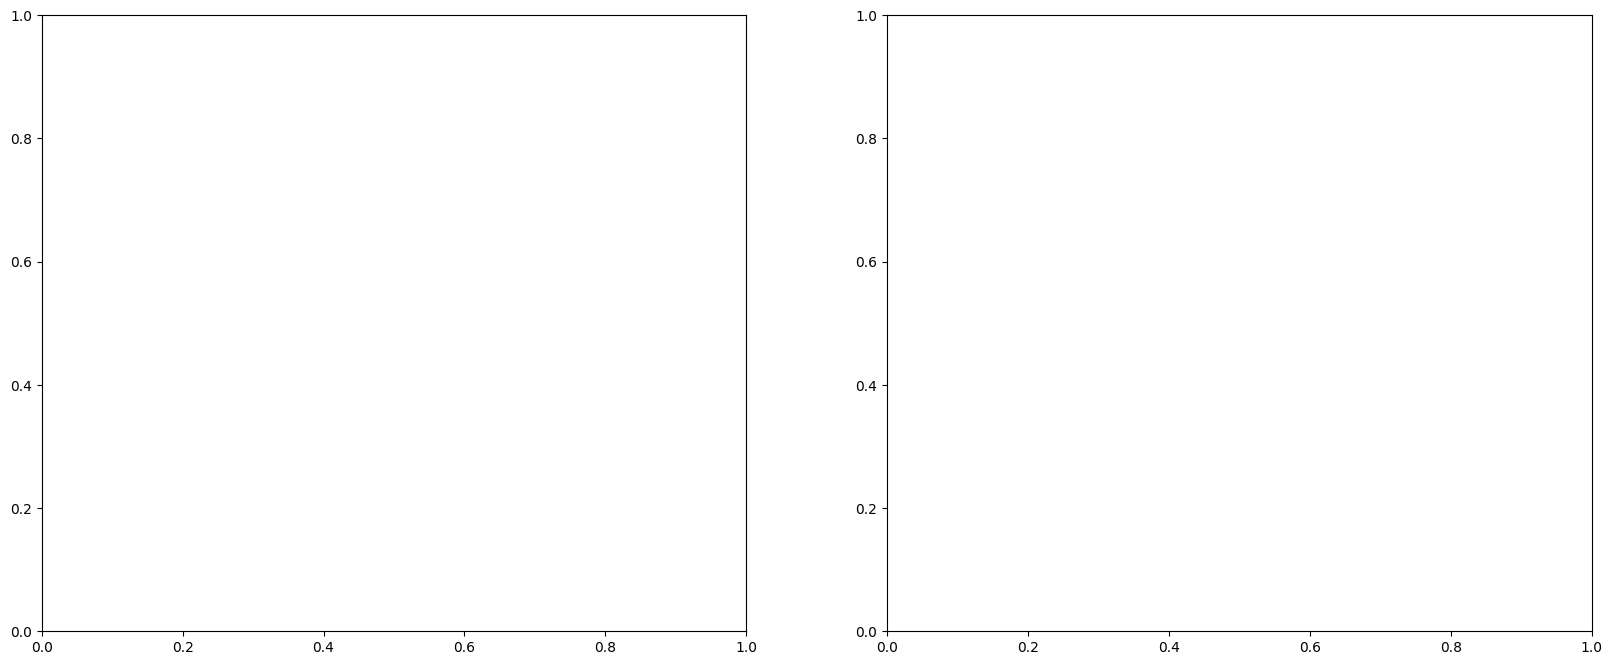

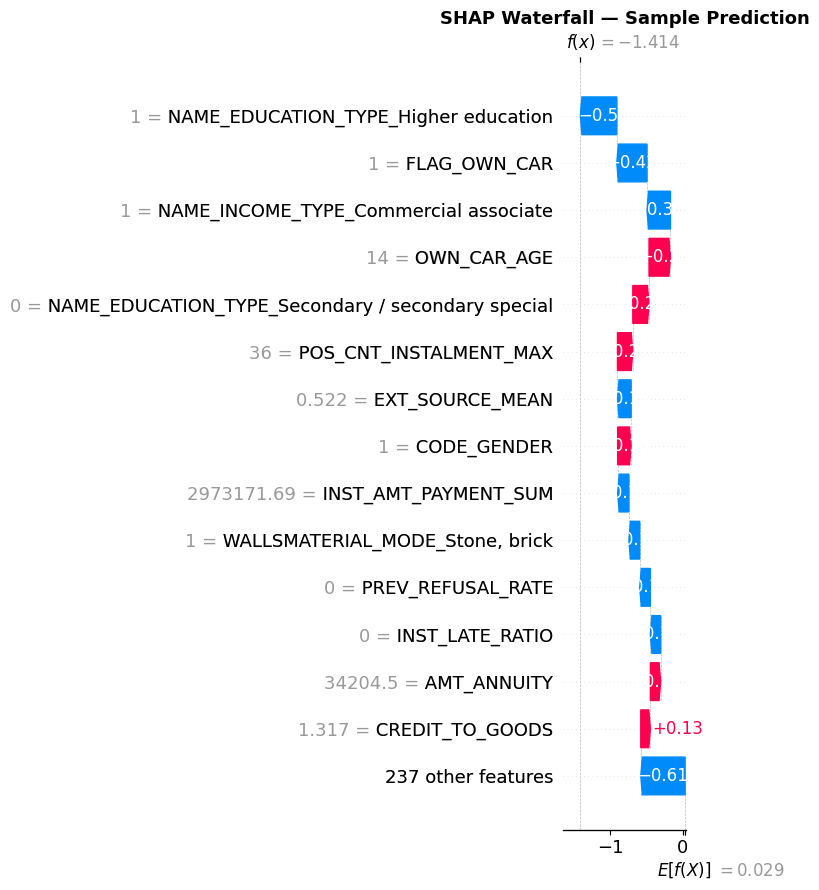

Waterfall plot saved!

Saving model artifacts...
Artifacts saved to: C:\Users\Pavan\Downloads\creditiq_sqlserver\creditiq\models\xgboost

Files:
  .gitkeep                                 0.00 MB
  shap_explainer.pkl                       4.43 MB
  shap_feature_importance.csv              0.01 MB
  test_predictions.csv                     0.94 MB
  xgboost_final.pkl                        1.54 MB


In [8]:
print("=" * 50)
print("SHAP WATERFALL PLOT")
print("=" * 50)

# Pick one defaulter and one non-defaulter to explain
defaulter_idx = np.where(y_test.values == 1)[0][0]
non_defaulter_idx = np.where(y_test.values == 0)[0][0]

# Get SHAP explanation object
explainer_v2 = shap.TreeExplainer(final_model)
shap_explanation = explainer_v2(shap_sample)

# ── Waterfall for a defaulter ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_explanation[0], max_display=15, show=False)
plt.title("SHAP Waterfall — Sample Prediction",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "14_shap_waterfall.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Waterfall plot saved!")

# ── Save full model artifacts ─────────────────────────────────
print("\nSaving model artifacts...")

# Save predictions
predictions_df = pd.DataFrame({
    "y_true":       y_test.values,
    "y_pred_proba": y_pred_proba,
    "y_pred":       y_pred
})
predictions_df.to_csv(MODELS_DIR / "test_predictions.csv", index=False)

# Save SHAP explainer
joblib.dump(explainer, MODELS_DIR / "shap_explainer.pkl")

print(f"Artifacts saved to: {MODELS_DIR}")
print("\nFiles:")
for f in MODELS_DIR.iterdir():
    print(f"  {f.name:<40} {f.stat().st_size/1024**2:.2f} MB")

In [9]:
print("=" * 60)
print("XGBOOST MODEL — COMPLETE SUMMARY")
print("=" * 60)

print(f"""
MODEL PERFORMANCE
-----------------
ROC-AUC:       0.7875  (industry: 0.72-0.78) ✓ ABOVE INDUSTRY
KS Statistic:  0.4342  (industry: 0.35-0.45) ✓ GOOD RANGE
Gini:          0.5750  (industry: 0.44-0.56) ✓ ABOVE INDUSTRY

CONFUSION MATRIX (threshold=0.5)
---------------------------------
True Negatives  (correctly predicted repaid):    53,892
True Positives  (correctly predicted default):    1,384
False Negatives (missed defaulters):              3,581
False Positives (false alarms):                   2,646

TOP 5 PREDICTIVE FEATURES (SHAP)
---------------------------------
1. EXT_SOURCE_MEAN              0.4408
2. FLAG_OWN_CAR                 0.1892
3. NAME_EDUCATION_TYPE_Higher   0.1729
4. POS_CNT_INSTALMENT_MAX       0.1477
5. ORGANIZATION_TYPE            0.1388

BEST HYPERPARAMETERS (Optuna)
------------------------------
n_estimators:      661
max_depth:         5
learning_rate:     0.0549
subsample:         0.7986
colsample_bytree:  0.8358
min_child_weight:  10
gamma:             1.2511
reg_alpha:         1.3744
reg_lambda:        1.2124

ARTIFACTS SAVED
---------------
models/xgboost/xgboost_final.pkl
models/xgboost/shap_explainer.pkl
models/xgboost/shap_feature_importance.csv
models/xgboost/test_predictions.csv
""")

XGBOOST MODEL — COMPLETE SUMMARY

MODEL PERFORMANCE
-----------------
ROC-AUC:       0.7875  (industry: 0.72-0.78) ✓ ABOVE INDUSTRY
KS Statistic:  0.4342  (industry: 0.35-0.45) ✓ GOOD RANGE
Gini:          0.5750  (industry: 0.44-0.56) ✓ ABOVE INDUSTRY

CONFUSION MATRIX (threshold=0.5)
---------------------------------
True Negatives  (correctly predicted repaid):    53,892
True Positives  (correctly predicted default):    1,384
False Negatives (missed defaulters):              3,581
False Positives (false alarms):                   2,646

TOP 5 PREDICTIVE FEATURES (SHAP)
---------------------------------
1. EXT_SOURCE_MEAN              0.4408
2. FLAG_OWN_CAR                 0.1892
3. NAME_EDUCATION_TYPE_Higher   0.1729
4. POS_CNT_INSTALMENT_MAX       0.1477
5. ORGANIZATION_TYPE            0.1388

BEST HYPERPARAMETERS (Optuna)
------------------------------
n_estimators:      661
max_depth:         5
learning_rate:     0.0549
subsample:         0.7986
colsample_bytree:  0.8358
min_child